In [90]:
from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt


def calculate_gait_mae(ground_truth: np.ndarray, prediction: np.ndarray, tolerance: int = 20):
    """
    Matches gait events and computes overall and per-class MAE in one pass.

    Args:
        ground_truth: Array of ground truth labels.
        prediction: Array of predicted labels.
        tolerance: Max distance to consider a match.

    Returns:
        A tuple containing:
        - overall_mae (float): The MAE across all matched events.
        - per_class_mae (dict): A dictionary mapping class labels to their MAE.
    """
    gt_indices = np.where(ground_truth > 0)[0]
    available_preds = list(np.where(prediction > 0)[0])
    
    # Store tuples of (label, absolute_error) for each successful match
    errors_by_class = []
    
    # Greedily match each ground truth event to the closest prediction
    for gt_idx in gt_indices:
        gt_label = ground_truth[gt_idx]
        best_dist = float('inf')
        best_match_idx = -1
        
        # Find the closest available prediction of the same class within tolerance
        for pred_idx in available_preds:
            if prediction[pred_idx] == gt_label:
                dist = abs(gt_idx - pred_idx)
                if dist <= tolerance and dist < best_dist:
                    best_dist = dist
                    best_match_idx = pred_idx
        
        # If a match is found, record its error and remove it from the pool
        if best_match_idx != -1:
            error = abs(gt_idx - best_match_idx)
            errors_by_class.append((gt_label, error))
            available_preds.remove(best_match_idx)
            
    if not errors_by_class:
        return 0.0, {}

    # --- Calculate Final Metrics ---
    
    # Overall MAE is the mean of all collected errors
    all_errors = [err for lbl, err in errors_by_class]
    overall_mae = np.mean(all_errors)
    
    # Per-class MAE is calculated by grouping errors by label
    unique_labels = sorted(np.unique([lbl for lbl, err in errors_by_class]))
    per_class_mae = {
        label: np.mean([err for lbl, err in errors_by_class if lbl == label])
        for label in unique_labels
    }
    
    return overall_mae, per_class_mae



# @hydra.main(config_path="../configs", config_name="train_config", version_base="1.3")
def eval():
    with initialize(config_path="../configs", job_name="train", version_base="1.3"):
        config = compose(config_name="train_config")
    pl.seed_everything(config.general.random_state)
    all_files = glob(config.general.data_path, recursive=True)
    all_files = np.sort(all_files)
    print(f"Processing: {len(all_files)} samples")

    ids = [int(i.split("/")[-1].split("_")[0]) for i in all_files]
    group_df = pd.read_csv(config.general.group_file, index_col="ID")
    group_df.columns = ["group", "status"]
    group_df = group_df[group_df.group.notna()]
    group_df.replace("h", 0, inplace=True)
    group_df.replace("p", 1, inplace=True)
    grouping = group_df.loc[ids].group.values

    skf = StratifiedKFold(
        n_splits=config.general.n_splits,
        shuffle=True,
        random_state=config.general.random_state,
    )

    # Outer loop for K-Fold cross-validation
    # This loop creates the primary TEST set for each fold.
    for fold, (train_val_index, test_index) in enumerate(
        skf.split(np.arange(len(ids)).reshape(-1, 1), grouping)
    ):
        print(
            f"=============== FOLD {fold + 1}/{config.general.n_splits} ================"
        )
        print("current_test set:", test_index)
        # Split data into a temporary training+validation set and the final test set
        X_train_val, X_test = (
            np.arange(len(ids))[train_val_index],
            np.arange(len(ids))[test_index],
        )
        y_train_val, y_test = grouping[train_val_index], grouping[test_index]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val,
            y_train_val,
            test_size=0.25,
            stratify=y_train_val,
            random_state=1,
        )

        # data_module = GaitDataModule(
        #     all_files,
        #     batch_size=config.data.batch_size,
        #     window_size=config.data.window_size,
        #     step_size=config.data.step_size,
        #     train_idx=X_train.squeeze(),
        #     val_idx=X_val.squeeze(),
        #     test_idx=test_index,
        #     expand_labels=config.data.expand_labels,
        #     acc_sheet_name=config.data.acc_sheet_name,
        #     num_workers=config.data.num_workers,
        # )

        model = LitSeq2Seq(
            input_dim=config.model.input_dim,
            output_dim=config.model.output_dim,
            hidden_dim=config.model.hidden_dim,
            num_layers=config.model.num_layers,
            dropout_prob=config.model.dropout_prob,
            learning_rate=config.model.learning_rate,
            teacher_forcing_ratio=config.model.teacher_forcing_ratio,
        )

        current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        run_name = f"GRU-expandlabel{config.data.expand_labels}_{current_time}"
        wandb_logger = WandbLogger(
            project=config.general.project_name,
            name=run_name,
            log_model="all",
        )
        checkpoint_callback = ModelCheckpoint(
            monitor=config.training.monitor_metric,
            mode=config.training.monitor_mode,
            save_top_k=config.training.save_top_k,
            dirpath=f"{config.general.project_name}/{run_name}/checkpoints/",
            filename="model-{epoch:02d}-{val_f1score:.2f}",
        )
        lr_monitor = LearningRateMonitor(logging_interval="step")

        trainer = pl.Trainer(
            max_epochs=config.training.num_epochs,
            accelerator=config.training.accelerator,
            devices=config.training.devices,
            log_every_n_steps=config.training.log_every_n_steps,
            check_val_every_n_epoch=config.training.check_val_every_n_epoch,
            enable_progress_bar=True,
            logger=wandb_logger,
            callbacks=[checkpoint_callback, lr_monitor],
        )

        print("Starting training...")

        #TODO
        # Get best model from wandb
        # Download and load best model weights
            
        checkpoint_callback.best_model_path = "/home/geromevivar/projects/gait_ml/backpain/GRU-expandlabel8_2025-10-09_14-23-13/checkpoints/model-epoch=25-val_f1score=0.94.ckpt"
        print(f"Best model: {checkpoint_callback.best_model_path}")
        device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        best_model = LitSeq2Seq.load_from_checkpoint(checkpoint_callback.best_model_path).to(device_)


        testset_f1_scores = []
        testset_mae = []
        testset_cm = []
        for curr_test_idx in test_index.tolist():
            test_datamodule = GaitDataModule(all_files,
                                             batch_size=1024,
                                             window_size=config.data.window_size,
                                             step_size=config.data.step_size,
                                             train_idx=X_train.squeeze(), 
                                             val_idx=X_val.squeeze(),
                                             test_idx=[curr_test_idx],
                                             expand_labels=config.data.expand_labels,
                                             acc_sheet_name="Linear Accelerometer",
                                             num_workers=16,
                                            )
            
            test_datamodule.setup("test")
            test_dataloader = test_datamodule.test_dataloader()
            best_model.eval()
            with torch.no_grad():
                pred=[]
                target=[]
                for sample_input, sample_target in test_dataloader:
                    sample_input = sample_input.to(device_)
                    sample_target = sample_target.to(device_)
                    print(sample_input.shape)
                    predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
                    pred.append(predicted_output)
                    target.append(sample_target)
                
                cur_pred = torch.concat(pred).reshape(-1, 3)
                cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
                cur_target = torch.concat(target).reshape(-1)
                reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
                
                print("Pred", cur_pred.shape, "Target", cur_target.shape)
                # cm = MulticlassConfusionMatrix(num_classes=3, normalize="true").to(device_)
                # cm.update(cur_pred, cur_target)
                # fig_, ax_ = cm.plot()
                # plt.show()
                
                ALIGN_TOLERANCE = 3
                merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
                merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
                aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
                
                
                cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
                cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                fig_, ax_ = cm.plot()
                plt.show()
                unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
                unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                ucm_tensor = unnormalized_cm.compute()
                testset_cm.append(ucm_tensor)
                print(ucm_tensor)
                
                num_classes = 3
                f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
                f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")
                overall, per_class = calculate_gait_mae(merged_targets, merged_preds)
                print(f"MAE overall: {overall.item():.4f} ✨")
                print(f"MAE per_class: {per_class} ✨")
                testset_f1_scores.append(f1_macro_score)
                testset_mae.append(overall)
            # break
        break
    return testset_f1_scores, testset_mae, testset_cm


Seed set to 42
/tmp/ipykernel_181083/1449247983.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Processing: 46 samples
=============== FOLD 1/5 ================
current_test set: [ 2  7 10 13 15 17 20 23 27 34]
Starting training...
Best model: /home/geromevivar/projects/gait_ml/backpain/GRU-expandlabel8_2025-10-09_14-23-13/checkpoints/model-epoch=25-val_f1score=0.94.ckpt
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_03_T1/03_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


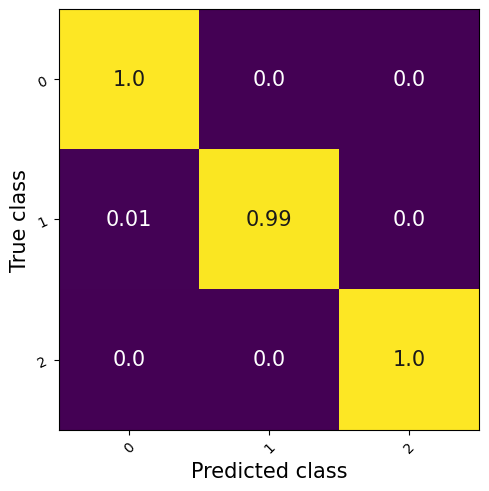

tensor([[12272,     1,     1],
        [    1,   134,     0],
        [    0,     0,   135]])
Macro F1-Score: 0.9963 ✨
MAE overall: 1.8444 ✨
MAE per_class: {np.int64(1): np.float64(1.8444444444444446), np.int64(2): np.float64(1.8444444444444446)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_09_T1/09_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


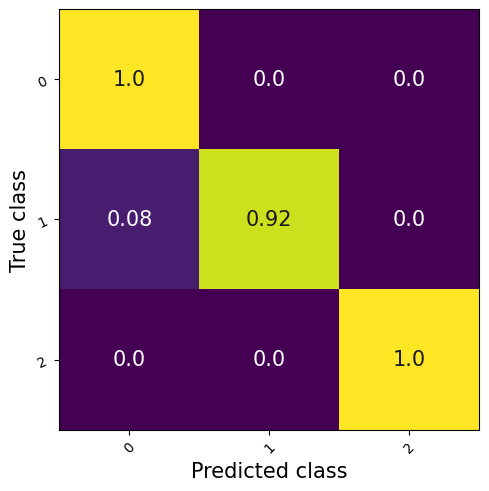

tensor([[12501,    10,     1],
        [   11,   133,     0],
        [    0,     0,   144]])
Macro F1-Score: 0.9742 ✨
MAE overall: 1.5714 ✨
MAE per_class: {np.int64(1): np.float64(1.993006993006993), np.int64(2): np.float64(1.1527777777777777)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_12_T1/12_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


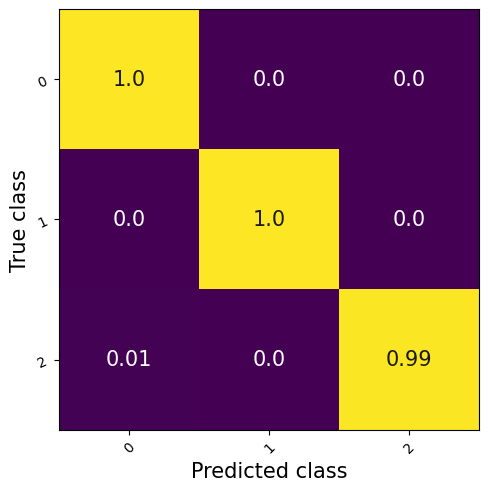

tensor([[12531,     1,     1],
        [    0,   134,     0],
        [    1,     0,   132]])
Macro F1-Score: 0.9962 ✨
MAE overall: 1.1648 ✨
MAE per_class: {np.int64(1): np.float64(0.9029850746268657), np.int64(2): np.float64(1.4285714285714286)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_15_T1/15_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


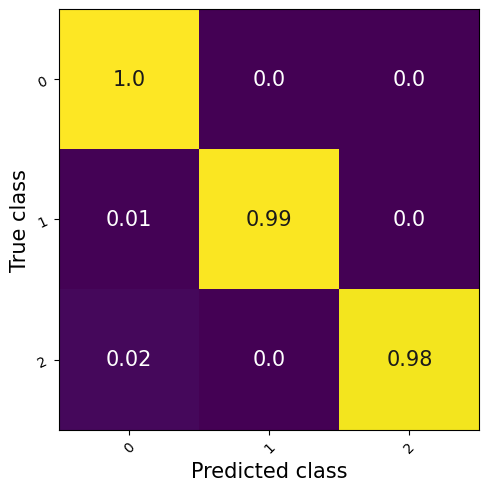

tensor([[12493,     3,     4],
        [    1,   149,     0],
        [    3,     0,   147]])
Macro F1-Score: 0.9877 ✨
MAE overall: 1.1167 ✨
MAE per_class: {np.int64(1): np.float64(0.9666666666666667), np.int64(2): np.float64(1.2666666666666666)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_17_T1/17_1_2mW_IPhone.xls
cropped_array shape: (55, 256, 7)
all_arrays shape: (55, 256, 7)
torch.Size([55, 256, 6])
Pred torch.Size([14080]) Target torch.Size([14080])


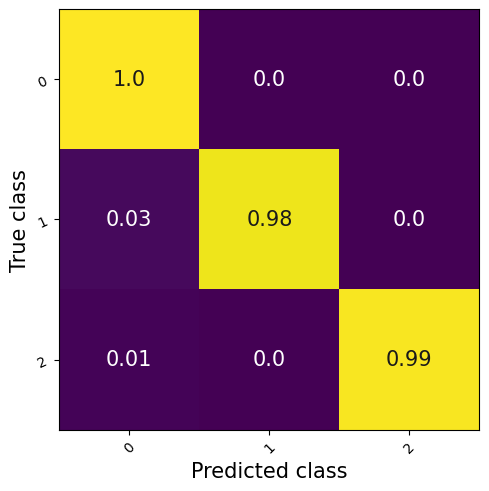

tensor([[13838,     2,     1],
        [    3,   117,     0],
        [    1,     0,   118]])
Macro F1-Score: 0.9901 ✨
MAE overall: 1.6555 ✨
MAE per_class: {np.int64(1): np.float64(1.7394957983193278), np.int64(2): np.float64(1.5714285714285714)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_19_T1/19_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


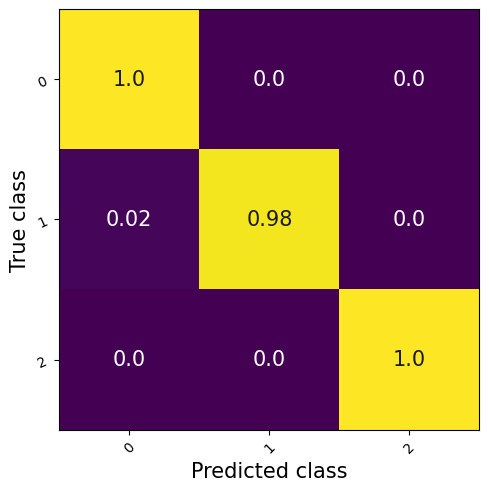

tensor([[12546,     3,     0],
        [    2,   124,     0],
        [    0,     0,   125]])
Macro F1-Score: 0.9933 ✨
MAE overall: 0.6135 ✨
MAE per_class: {np.int64(1): np.float64(0.8015873015873016), np.int64(2): np.float64(0.424)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_23_T1/23_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


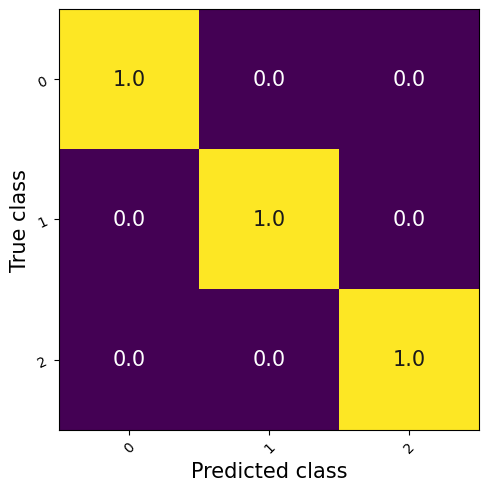

tensor([[12541,     2,     1],
        [    0,   128,     0],
        [    0,     0,   128]])
Macro F1-Score: 0.9961 ✨
MAE overall: 1.5039 ✨
MAE per_class: {np.int64(1): np.float64(1.03125), np.int64(2): np.float64(1.9765625)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_26_T1/26_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


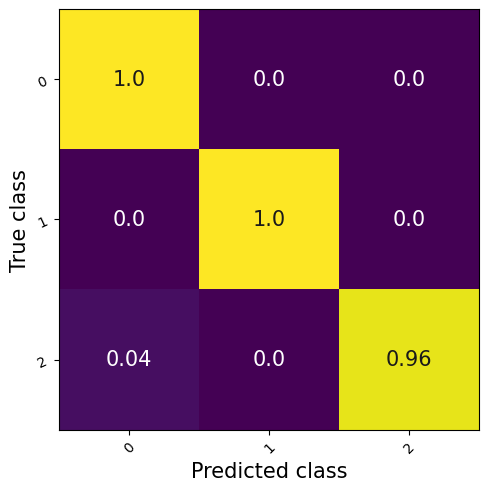

tensor([[12523,     1,     6],
        [    0,   135,     0],
        [    5,     0,   130]])
Macro F1-Score: 0.9851 ✨
MAE overall: 1.5926 ✨
MAE per_class: {np.int64(1): np.float64(1.3111111111111111), np.int64(2): np.float64(1.874074074074074)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_30_T1/30_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


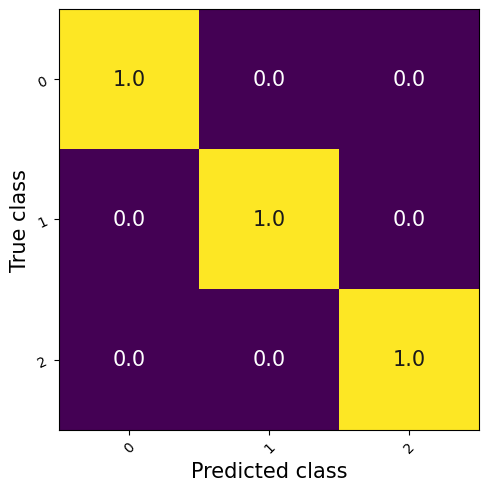

tensor([[12539,     3,     1],
        [    0,   129,     0],
        [    0,     0,   128]])
Macro F1-Score: 0.9948 ✨
MAE overall: 0.9844 ✨
MAE per_class: {np.int64(1): np.float64(0.9612403100775194), np.int64(2): np.float64(1.0078125)} ✨
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_37_T1/37_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


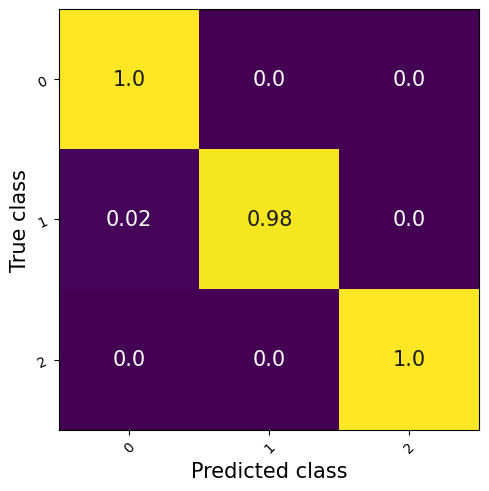

tensor([[12540,     3,     2],
        [    2,   126,     0],
        [    0,     0,   127]])
Macro F1-Score: 0.9908 ✨
MAE overall: 1.2627 ✨
MAE per_class: {np.int64(1): np.float64(1.4296875), np.int64(2): np.float64(1.094488188976378)} ✨


In [91]:
testset_f1_scores, testset_mae, testset_cm = eval()

In [83]:
cm = torch.stack(testset_cm).sum(0)/torch.stack(testset_cm).sum((0, 2))
cm.numpy().round(3)

tensor([[9.9963e-01, 2.1821e-02, 1.3595e-02],
        [1.5826e-04, 9.8495e-01, 0.0000e+00],
        [7.9132e-05, 0.0000e+00, 9.9245e-01]])